# Reproduce Yang et al. (2026) angular power spectra

This notebook computes a subset of the statistics in
**Yang et al. (2026, MNRAS 548, 1–26)** from the local
`yang26/lightcone0` integrated HEALPix maps:

| Target (paper) | Quantity |
|----------------|----------|
| Fig. 8 (left) | CIB auto-power spectra at 353 / 545 / 857 GHz |
| Table 3 | CIB frequency decorrelation $C_{\nu\nu'}/\sqrt{C_{\nu\nu}C_{\nu'\nu'}}$ |
| Fig. 10 (left) | CIB–tSZ ($y$) cross-power spectra |
| Fig. 10 (right) | CIB–CMB lensing ($\kappa$) cross-power spectra |

## Method (Yang et al. 2026, §3.1)

- Full-sky maps $\Rightarrow$ we use `healpy.anafast` (paper uses NaMaster; equivalent for full sky).
- Pixel-window deconvolution via `healpy.pixwin` at the map $N_\mathrm{side}$.
- Bandpowers with $\Delta\ell = 7$, then Savitzky–Golay smoothing (order 3, window 15) for display.
- Paper curves average **eight** L2p8 lightcones; here we have only **`lightcone0`**, so there is no sample-variance band.

## Units

- CIB maps are treated as intensity in $\mathrm{Jy\,sr^{-1}}$ (consistent with Planck-scale monopoles $\sim 10^5\,\mathrm{Jy\,sr^{-1}}$).
- CIB auto: $D_\ell = \ell(\ell+1)C_\ell/(2\pi)$ in $[\mathrm{Jy\,sr^{-1}}]^2$.
- CIB–$y$: $C_\ell$ in $10^{-6}\,\mathrm{Jy\,sr^{-1}}$ (as in Fig. 10).
- CIB–$\kappa$: $C_\ell$ in $\mathrm{Jy\,sr^{-1}}$.

> **Kernel**: `cosmo_env` or `tpu_rl`. Toggle `USE_DOWNGRADE` below for a fast preview ($N_\mathrm{side}=256$) vs native ($4096$).

In [1]:
from pathlib import Path

import h5py
import healpy as hp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

# ---------------------------------------------------------------------------
# Global controls
# ---------------------------------------------------------------------------
DATA_DIR = Path(
    "/home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo"
    "/L2p8_m9/integrated_maps/yang26/lightcone0_shells"
)
NSIDE_FULL = 4096
NSIDE_DOWNGRADE = 256
USE_DOWNGRADE = False   # True -> Nside=256 preview; False -> native 4096
NSIDE = NSIDE_DOWNGRADE if USE_DOWNGRADE else NSIDE_FULL

LMAX = 3 * NSIDE - 1
DELTA_ELL = 7          # Yang et al. bandpower width
SG_WINDOW = 15         # Savitzky–Golay window (odd)
SG_ORDER = 3
ANAFAST_ITER = 0       # 0 is faster; raise for slightly better accuracy

assert DATA_DIR.is_dir(), f"Missing data directory: {DATA_DIR}"
print(f"USE_DOWNGRADE={USE_DOWNGRADE} -> Nside={NSIDE}, lmax={LMAX}")

USE_DOWNGRADE=False -> Nside=4096, lmax=12287


In [2]:
# ---------------------------------------------------------------------------
# Publication-quality Matplotlib + LaTeX
# ---------------------------------------------------------------------------
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "legend.frameon": False,
})

# Distinct colours for the three main CIB bands (colourblind-friendly)
CIB_COLORS = {
    217: "#0072B2",
    353: "#E69F00",
    545: "#009E73",
    857: "#D55E00",
}

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


def savefig(fig, name: str) -> None:
    """Save PDF + PNG for papers."""
    fig.savefig(FIG_DIR / f"{name}.pdf")
    fig.savefig(FIG_DIR / f"{name}.png")
    print(f"Wrote {FIG_DIR / name}.pdf")

## 1. Load maps

Maps are native $N_\mathrm{side}=4096$. When `USE_DOWNGRADE=True` we degrade
with `ud_grade` before computing spectra (faster, but underestimates small-scale
power relative to the published $N_\mathrm{side}=4096$ curves).

In [3]:
FILES = {
    "kappa": "CMB_lensing_rot_same_rot.hdf5",
    "tsz": "lensed_tSZ_rot_same_rot.hdf5",
    "cib217": "lensed_CIB_rot_BANDPASS_F217_three_params_same_rot.hdf5",
    "cib353": "lensed_CIB_rot_BANDPASS_F353_three_params_same_rot.hdf5",
    "cib545": "lensed_CIB_rot_BANDPASS_F545_three_params_same_rot.hdf5",
    "cib857": "lensed_CIB_rot_BANDPASS_F857_three_params_same_rot.hdf5",
}


def load_map(name: str) -> np.ndarray:
    path = DATA_DIR / FILES[name]
    with h5py.File(path, "r") as f:
        m = f["data"][:].astype(np.float64)
    if m.size != 12 * NSIDE_FULL ** 2:
        raise ValueError(f"{path.name}: unexpected size {m.size}")
    if USE_DOWNGRADE:
        m = hp.ud_grade(m, NSIDE)
    return m


print("Loading maps (this can take a minute at Nside=4096)...")
maps = {k: load_map(k) for k in FILES}
for k, m in maps.items():
    print(f"  {k:8s}: mean={m.mean():.4e}, std={m.std():.4e}, npix={m.size:,}")

Loading maps (this can take a minute at Nside=4096)...
  kappa   : mean=5.3154e-05, std=7.7303e-02, npix=201,326,592
  tsz     : mean=1.6109e-06, std=2.0697e-06, npix=201,326,592
  cib217  : mean=4.2928e+04, std=1.3296e+04, npix=201,326,592
  cib353  : mean=1.7042e+05, std=5.0706e+04, npix=201,326,592
  cib545  : mean=4.6901e+05, std=1.3649e+05, npix=201,326,592
  cib857  : mean=9.4807e+05, std=3.0248e+05, npix=201,326,592


## 2. Power-spectrum helpers

For full-sky maps,

$$
C_\ell^{ab}
=
\frac{1}{2\ell+1}
\sum_{m=-\ell}^{\ell}
a_{\ell m}^{a}\,a_{\ell m}^{b\,*},
$$

estimated with `anafast`. Pixel-window deconvolution:

$$
C_\ell^{\mathrm{corr}}
=
\frac{C_\ell^{\mathrm{raw}}}{W_\ell^{\mathrm{pix}\,2}}
\qquad
(W_\ell^{\mathrm{pix}} = \texttt{pixwin}(N_\mathrm{side})).
$$

Bandpowers average over bins of width $\Delta\ell=7$.

In [4]:
def compute_cl(map_a: np.ndarray, map_b: np.ndarray | None = None) -> np.ndarray:
    """Auto- or cross-spectrum with mean subtraction and pixel-window deconvolution."""
    a = map_a - np.mean(map_a)
    if map_b is None:
        cl = hp.anafast(a, lmax=LMAX, iter=ANAFAST_ITER)
    else:
        b = map_b - np.mean(map_b)
        cl = hp.anafast(a, b, lmax=LMAX, iter=ANAFAST_ITER)
    pixwin = hp.pixwin(NSIDE, lmax=LMAX)
    # Avoid divide-by-zero at very high ell where pixwin ~ 0
    safe = pixwin > 1e-6
    cl_corr = np.full_like(cl, np.nan)
    cl_corr[safe] = cl[safe] / pixwin[safe] ** 2
    return cl_corr


def bin_cl(cl: np.ndarray, delta_ell: int = DELTA_ELL) -> tuple[np.ndarray, np.ndarray]:
    """Bin C_ell into equal-width multipole bands; return (ell_eff, C_binned)."""
    ell = np.arange(cl.size)
    # Skip monopole/dipole for cosmological spectra
    start = 2
    n_bins = (cl.size - start) // delta_ell
    ell_b = np.empty(n_bins)
    cl_b = np.empty(n_bins)
    for i in range(n_bins):
        lo = start + i * delta_ell
        hi = lo + delta_ell
        sl = slice(lo, hi)
        w = np.isfinite(cl[sl])
        ell_b[i] = ell[sl][w].mean() if w.any() else np.nan
        cl_b[i] = cl[sl][w].mean() if w.any() else np.nan
    return ell_b, cl_b


def smooth_for_display(y: np.ndarray, window: int = SG_WINDOW, order: int = SG_ORDER) -> np.ndarray:
    """Savitzky–Golay smoothing used in Yang et al. for visualisation only."""
    if y.size < window:
        return y
    # Work in log space when all positive to preserve dynamic range
    if np.all(y[np.isfinite(y)] > 0):
        return np.exp(savgol_filter(np.log(y), window, order))
    return savgol_filter(y, window, order)


def dl_from_cl(ell: np.ndarray, cl: np.ndarray) -> np.ndarray:
    """D_ell = ell(ell+1) C_ell / (2 pi)."""
    return ell * (ell + 1.0) * cl / (2.0 * np.pi)

## 3. Compute spectra

We compute CIB autos, CIB–CIB frequency crosses (for decorrelation),
CIB–$y$, and CIB–$\kappa$. At native $N_\mathrm{side}=4096$ this is the slow step.

In [5]:
CIB_FREQS = [217, 353, 545, 857]
cib_keys = {nu: f"cib{nu}" for nu in CIB_FREQS}

cls = {}

# CIB auto-spectra
for nu in CIB_FREQS:
    print(f"CIB auto {nu} GHz...")
    cls[("cib", nu, nu)] = compute_cl(maps[cib_keys[nu]])

# CIB–CIB cross (upper triangle) for decorrelation
for i, nu1 in enumerate(CIB_FREQS):
    for nu2 in CIB_FREQS[i + 1:]:
        print(f"CIB cross {nu1}×{nu2} GHz...")
        cls[("cib", nu1, nu2)] = compute_cl(maps[cib_keys[nu1]], maps[cib_keys[nu2]])

# CIB × tSZ and CIB × kappa
for nu in CIB_FREQS:
    print(f"CIB×tSZ and CIB×κ at {nu} GHz...")
    cls[("cib_tsz", nu)] = compute_cl(maps[cib_keys[nu]], maps["tsz"])
    cls[("cib_kappa", nu)] = compute_cl(maps[cib_keys[nu]], maps["kappa"])

# Also tSZ and kappa autos (handy diagnostics)
print("tSZ and κ autos...")
cls[("tsz",)] = compute_cl(maps["tsz"])
cls[("kappa",)] = compute_cl(maps["kappa"])
print("Done.")

CIB auto 217 GHz...
CIB auto 353 GHz...
CIB auto 545 GHz...
CIB auto 857 GHz...
CIB cross 217×353 GHz...
CIB cross 217×545 GHz...
CIB cross 217×857 GHz...
CIB cross 353×545 GHz...
CIB cross 353×857 GHz...
CIB cross 545×857 GHz...
CIB×tSZ and CIB×κ at 217 GHz...
CIB×tSZ and CIB×κ at 353 GHz...
CIB×tSZ and CIB×κ at 545 GHz...
CIB×tSZ and CIB×κ at 857 GHz...
tSZ and κ autos...
Done.


## 4. CIB auto-power spectra (cf. Fig. 8, left)

Yang et al. fit the three-parameter SED to Lenz et al. (2019) at 353/545/857 GHz.
We plot $D_\ell$ for those bands (plus 217 GHz as a consistency check).
Expect qualitative agreement with their Fig. 8; quantitative match improves with
`USE_DOWNGRADE=False` and would tighten further if averaged over all eight lightcones.

Wrote ../figures/cib_auto_spectra.pdf


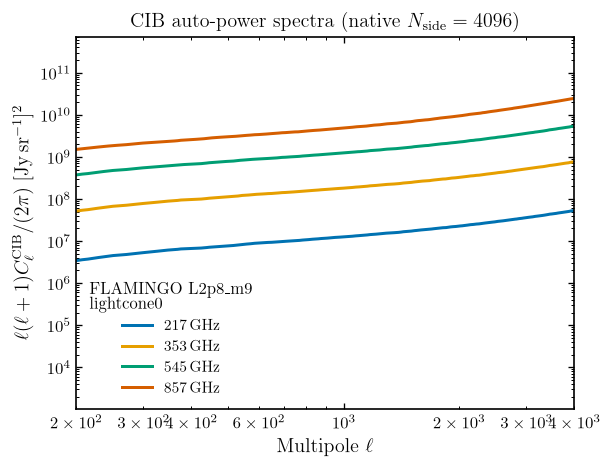

In [11]:
fig, ax = plt.subplots(figsize=(5.2, 4.0))

for nu in CIB_FREQS:
    ell_b, cl_b = bin_cl(cls[("cib", nu, nu)])
    dl_b = dl_from_cl(ell_b, cl_b)
    dl_s = smooth_for_display(dl_b)
    ax.loglog(
        ell_b, dl_s,
        color=CIB_COLORS[nu],
        lw=1.8,
        label=rf"${nu}\,\mathrm{{GHz}}$",
    )

ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(
    r"$\ell(\ell+1)C_\ell^{\mathrm{CIB}}/(2\pi)\;[\mathrm{Jy}\,\mathrm{sr}^{-1}]^{2}$"
)
ax.set_xlim(200, min(LMAX, 4000))
ax.legend(title=r"FLAMINGO L2p8\_m9" + "\n" + r"lightcone0",
          loc="lower left")
ax.set_title(
    r"CIB auto-power spectra"
    + (r" (downgraded $N_{\mathrm{side}}=256$)" if USE_DOWNGRADE
       else r" (native $N_{\mathrm{side}}=4096$)"),
)
fig.tight_layout()
savefig(fig, "cib_auto_spectra")
plt.show()

## 5. CIB frequency decorrelation (cf. Table 3)

Decorrelation coefficient averaged over $150 < \ell < 1000$:

$$
r_{\nu\nu'}
=
\left\langle
\frac{C_\ell^{\nu\nu'}}
{\sqrt{C_\ell^{\nu\nu}\,C_\ell^{\nu'\nu'}}}
\right\rangle_{150<\ell<1000}.
$$

Yang et al. report e.g. $r_{353\times545}\approx 0.98$ and $r_{217\times857}\approx 0.84$ for L2p8\_m9.

       ν1×ν2    r_mean     r_std
----------------------------------
 217×353      0.993     0.000
 217×545      0.956     0.003
 217×857      0.842     0.013
 353×545      0.984     0.001
 353×857      0.896     0.009
 545×857      0.960     0.004
Wrote ../figures/cib_decorrelation.pdf


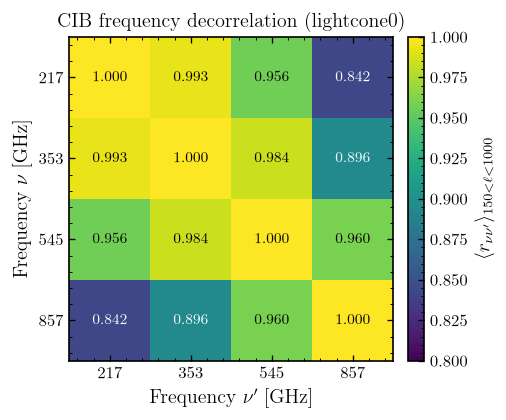

In [7]:
def decorrelation(cl_x: np.ndarray, cl_a: np.ndarray, cl_b: np.ndarray,
                  ell_lo: int = 150, ell_hi: int = 1000) -> tuple[float, float]:
    ell = np.arange(cl_x.size)
    m = (ell > ell_lo) & (ell < ell_hi) & np.isfinite(cl_x) & (cl_a > 0) & (cl_b > 0)
    r = cl_x[m] / np.sqrt(cl_a[m] * cl_b[m])
    return float(r.mean()), float(r.std())


print(f"{'ν1×ν2':>12s}  {'r_mean':>8s}  {'r_std':>8s}")
print("-" * 34)
rows = []
for i, nu1 in enumerate(CIB_FREQS):
    for nu2 in CIB_FREQS[i + 1:]:
        r_m, r_s = decorrelation(
            cls[("cib", nu1, nu2)],
            cls[("cib", nu1, nu1)],
            cls[("cib", nu2, nu2)],
        )
        rows.append((nu1, nu2, r_m, r_s))
        print(f"{nu1:4d}×{nu2:<4d}  {r_m:8.3f}  {r_s:8.3f}")

# Matrix heatmap
n = len(CIB_FREQS)
R = np.eye(n)
for nu1, nu2, r_m, _ in rows:
    i, j = CIB_FREQS.index(nu1), CIB_FREQS.index(nu2)
    R[i, j] = R[j, i] = r_m

fig, ax = plt.subplots(figsize=(4.2, 3.6))
im = ax.imshow(R, vmin=0.8, vmax=1.0, cmap="viridis", origin="upper")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([rf"${nu}$" for nu in CIB_FREQS])
ax.set_yticklabels([rf"${nu}$" for nu in CIB_FREQS])
ax.set_xlabel(r"Frequency $\nu'\;[\mathrm{GHz}]$")
ax.set_ylabel(r"Frequency $\nu\;[\mathrm{GHz}]$")
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{R[i, j]:.3f}", ha="center", va="center",
                color="white" if R[i, j] < 0.92 else "black", fontsize=9)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r"$\langle r_{\nu\nu'}\rangle_{150<\ell<1000}$")
ax.set_title(r"CIB frequency decorrelation (lightcone0)")
fig.tight_layout()
savefig(fig, "cib_decorrelation")
plt.show()

## 6. CIB–tSZ and CIB–$\kappa$ cross-spectra (cf. Fig. 10)

Left: $C_\ell^{\mathrm{CIB}\times y}$ in units of $10^{-6}\,\mathrm{Jy\,sr^{-1}}$.
Right: $C_\ell^{\mathrm{CIB}\times\kappa}$ in $\mathrm{Jy\,sr^{-1}}$.

Paper shaded bands come from the scatter across eight lightcones; with a single
realization we show the smoothed bandpowers only. Expect the same qualitative
frequency ordering (higher frequency $\Rightarrow$ higher CIB amplitude).

Wrote ../figures/cib_tsz_kappa_cross.pdf


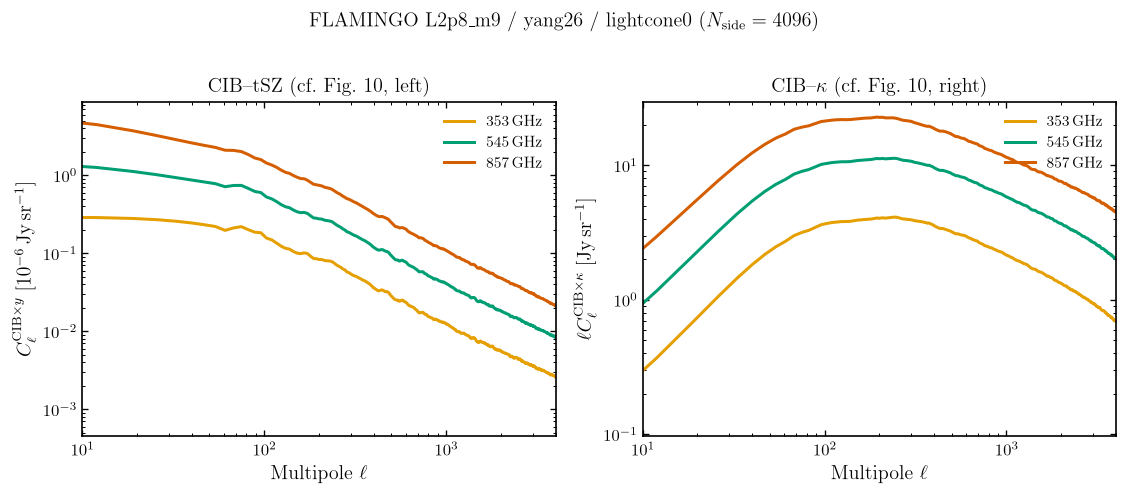

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.0), sharex=True)

plot_freqs = [353, 545, 857]  # main bands shown in Fig. 10

for nu in plot_freqs:
    ell_b, cl_by = bin_cl(cls[("cib_tsz", nu)])
    ell_k, cl_bk = bin_cl(cls[("cib_kappa", nu)])
    y_tsz = smooth_for_display(cl_by * 1.0e6)   # -> 1e-6 Jy/sr
    y_kap = smooth_for_display(cl_bk)           # Jy/sr

    axes[0].loglog(
        ell_b, np.abs(y_tsz),
        color=CIB_COLORS[nu], lw=1.8,
        label=rf"${nu}\,\mathrm{{GHz}}$",
    )
    axes[1].loglog(
        ell_k, ell_k* np.abs(y_kap),
        color=CIB_COLORS[nu], lw=1.8,
        label=rf"${nu}\,\mathrm{{GHz}}$",
    )

axes[0].set_xlabel(r"Multipole $\ell$")
axes[1].set_xlabel(r"Multipole $\ell$")
axes[0].set_ylabel(
    r"$C_\ell^{\mathrm{CIB}\times y}\;[10^{-6}\,\mathrm{Jy}\,\mathrm{sr}^{-1}]$"
)
axes[1].set_ylabel(
    r"$\ell C_\ell^{\mathrm{CIB}\times\kappa}\;[\mathrm{Jy}\,\mathrm{sr}^{-1}]$"
)
axes[0].set_xlim(10, min(LMAX, 4000))
axes[0].set_title(r"CIB--tSZ (cf.\ Fig.~10, left)")
axes[1].set_title(r"CIB--$\kappa$ (cf.\ Fig.~10, right)")
axes[0].legend(loc="upper right")
axes[1].legend(loc="upper right")

fig.suptitle(
    r"FLAMINGO L2p8\_m9 / yang26 / lightcone0"
    + (rf" ($N_{{\mathrm{{side}}}}={NSIDE}$, downgraded)" if USE_DOWNGRADE
       else rf" ($N_{{\mathrm{{side}}}}={NSIDE}$)"),
    y=1.02,
)
fig.tight_layout()
savefig(fig, "cib_tsz_kappa_cross")
plt.show()

## 7. Diagnostics: $y$ and $\kappa$ autos

Quick sanity checks against the expected shapes in Yang et al. Figs. 6 and §3.2
(not a full reproduction of those figures).

Wrote ../figures/tsz_kappa_auto_diagnostics.pdf


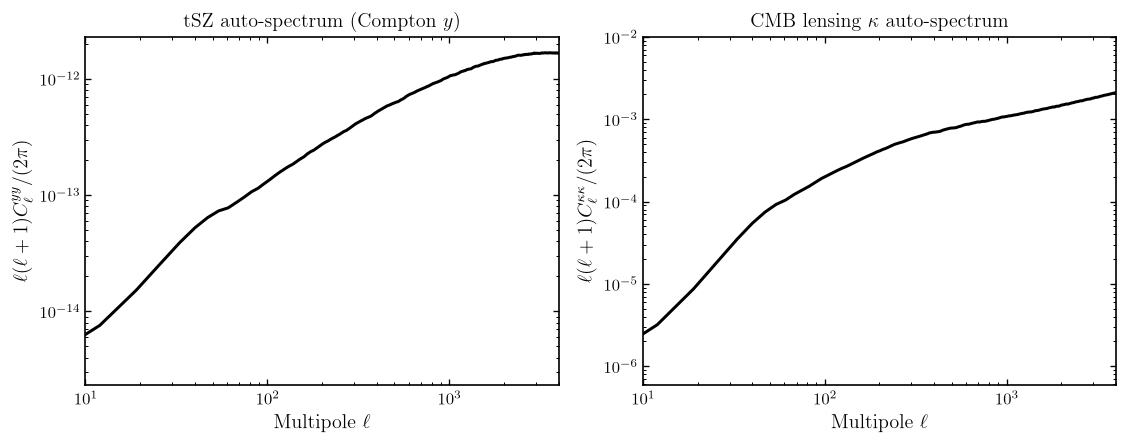

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))

ell_y, cl_y = bin_cl(cls[("tsz",)])
ell_k, cl_k = bin_cl(cls[("kappa",)])
dl_y = smooth_for_display(dl_from_cl(ell_y, cl_y))
dl_k = smooth_for_display(dl_from_cl(ell_k, cl_k))

axes[0].loglog(ell_y, dl_y, color="#000000", lw=1.8)
axes[0].set_xlabel(r"Multipole $\ell$")
axes[0].set_ylabel(r"$\ell(\ell+1)C_\ell^{yy}/(2\pi)$")
axes[0].set_title(r"tSZ auto-spectrum (Compton $y$)")
axes[0].set_xlim(10, min(LMAX, 4000))

axes[1].loglog(ell_k, dl_k, color="#000000", lw=1.8)
axes[1].set_xlabel(r"Multipole $\ell$")
axes[1].set_ylabel(r"$\ell(\ell+1)C_\ell^{\kappa\kappa}/(2\pi)$")
axes[1].set_title(r"CMB lensing $\kappa$ auto-spectrum")
axes[1].set_xlim(10, min(LMAX, 4000))

fig.tight_layout()
savefig(fig, "tsz_kappa_auto_diagnostics")
plt.show()

## Notes on reproduction fidelity

1. **Single lightcone**: published curves average eight L2p8 observers; we only
   analyse `lightcone0`, so large-scale ($\ell\lesssim 300$) CIB–$y$ scatter can differ.
2. **Resolution**: set `USE_DOWNGRADE=False` for a fair comparison to Fig. 8 / 10
   (native $N_\mathrm{side}=4096$). Downgraded runs are for development only.
3. **Estimator**: `anafast` on the full sky matches NaMaster for this case; we do
   not apply a bright-source mask (Yang et al. note masking has negligible effect
   on FLAMINGO CIB).
4. **External data**: Lenz et al. (2019) / Planck points are not overplotted here;
   compare visually to Fig. 8 and Fig. 10 of the paper.

### References

1. Yang et al. (2026), MNRAS 548, 1–26, doi:10.1093/mnras/stag625
2. Lenz, Doré & Lagache (2019), CIB auto- and cross-power spectra
3. Alonso et al. (2019), NaMaster